In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

warnings.filterwarnings(
    "ignore",
    message=r"invalid value encountered in log10",
    category=RuntimeWarning,
    module=r".*specparam.*",
)


# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules

from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [3]:
cell_num =14 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 14  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 14

## Step 0: Get loaded data 

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c14_lfp.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c14patch_filt.npy'


In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

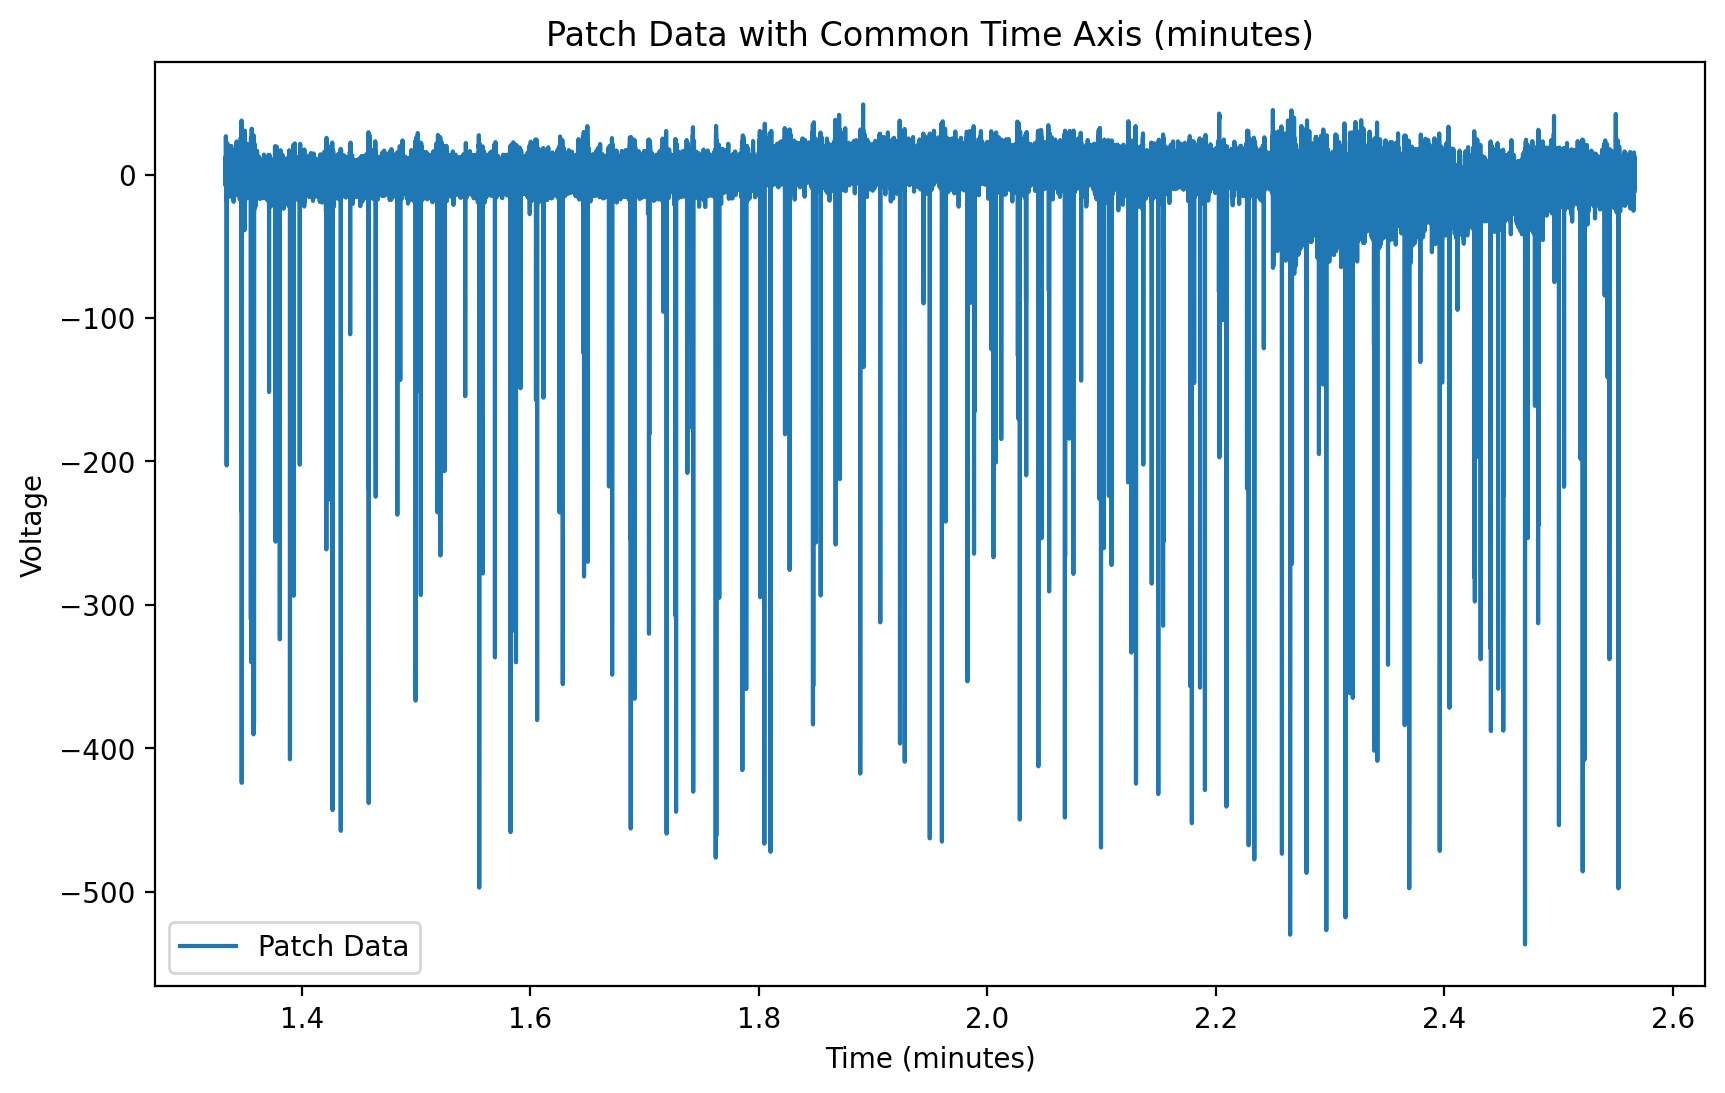

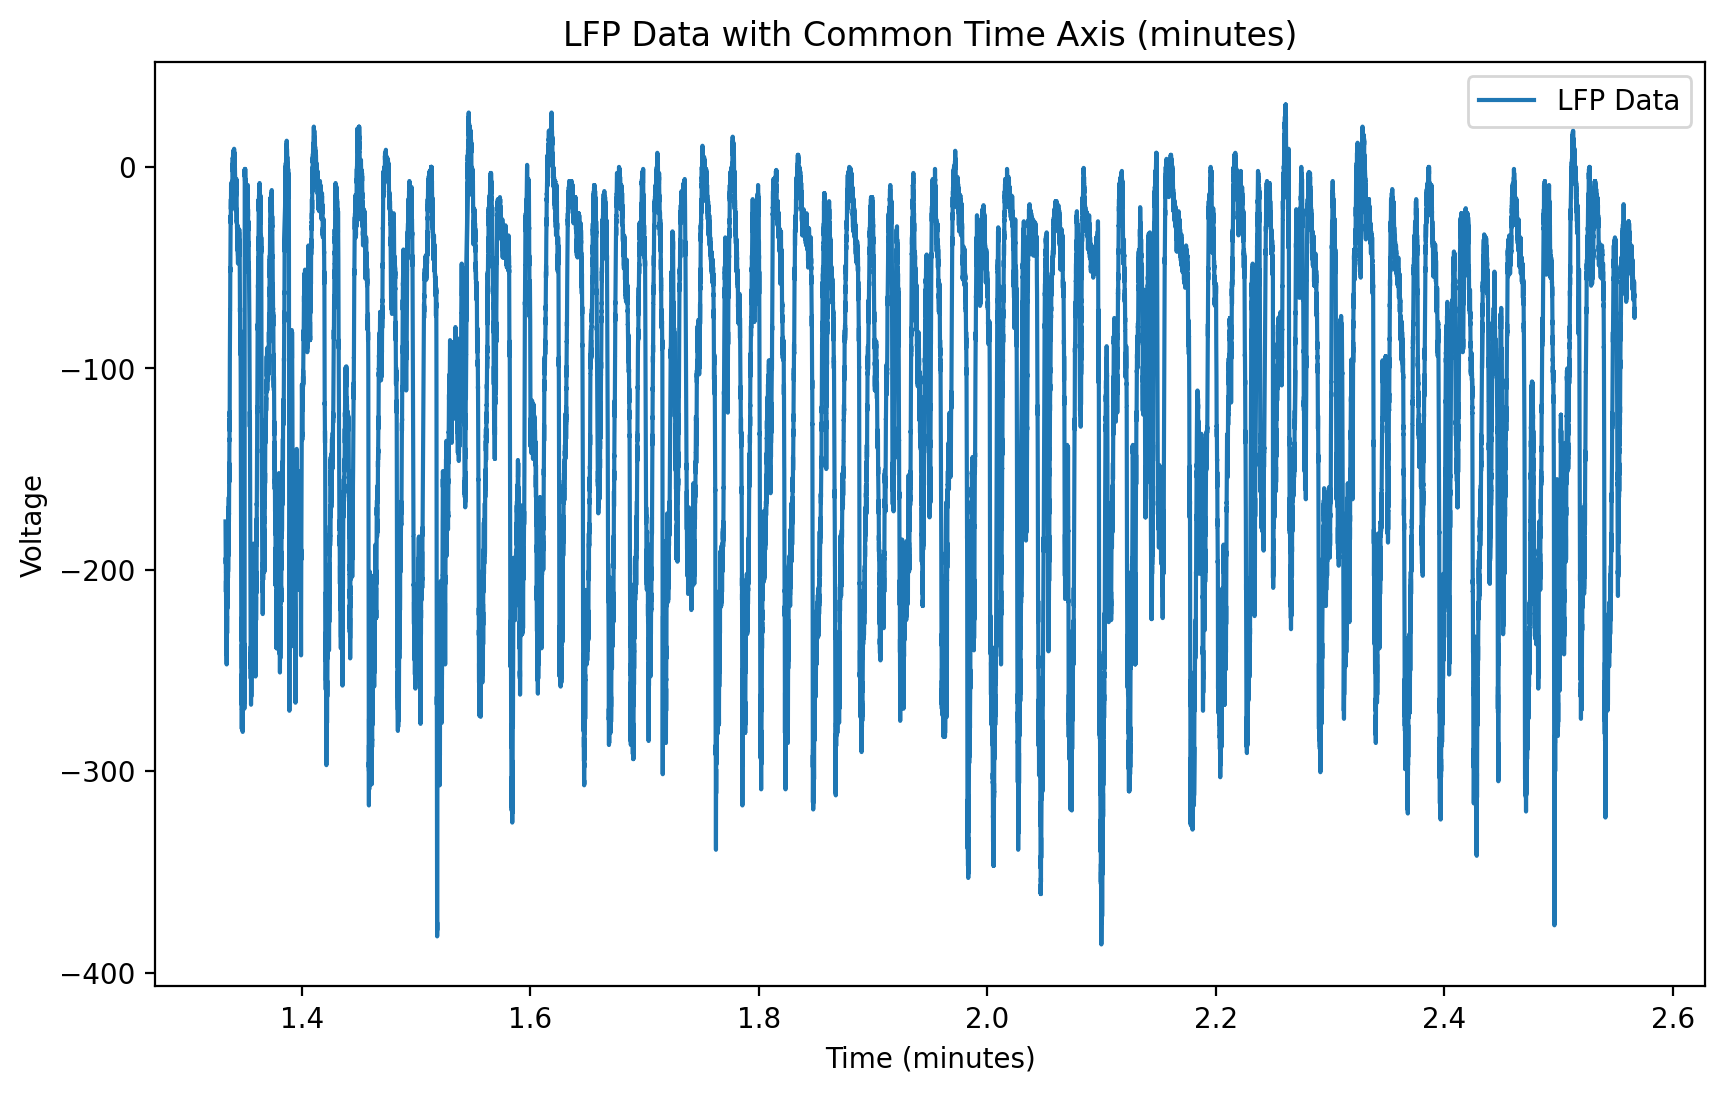

In [6]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

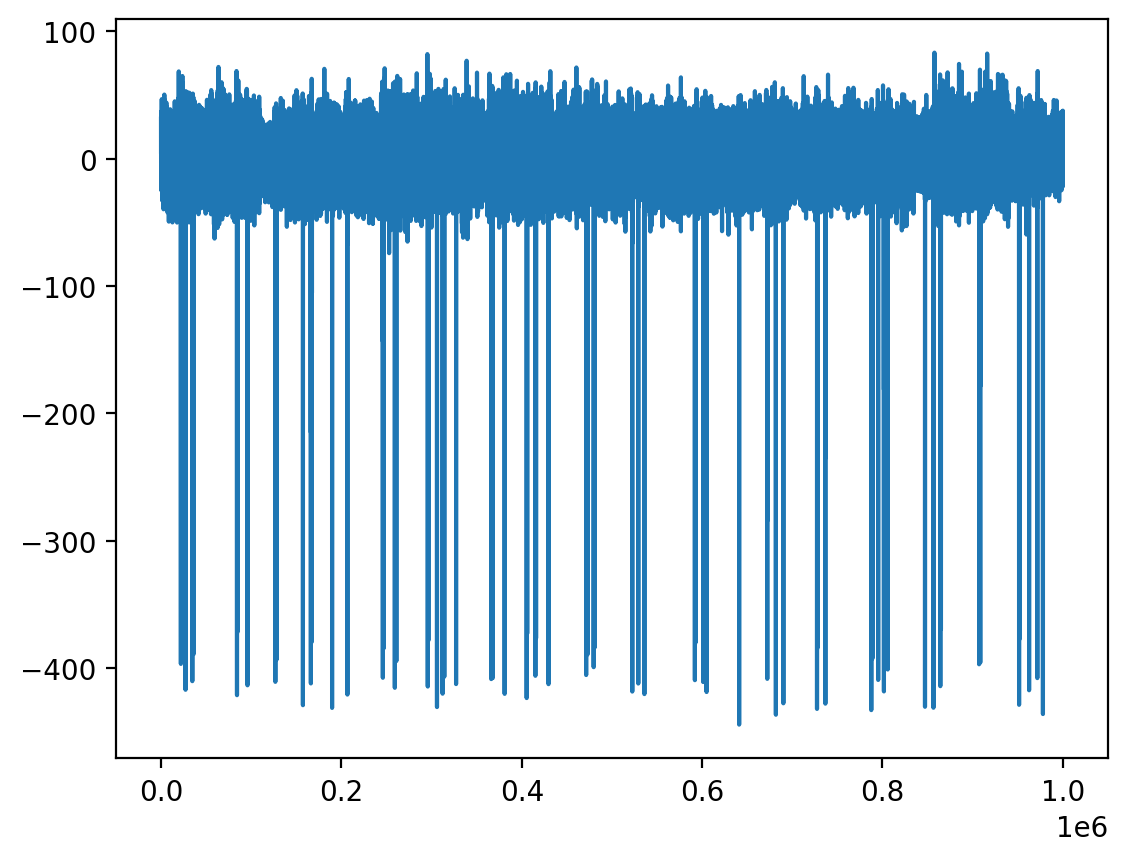

In [7]:
plt.plot(patch_filt[:1000000] )

In [8]:



#threshold in mVs
sp = Spike(thresh_amp=100, window_length=(5., 5.), smooth_frac=.01)

In [9]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=True)

Spike:   0%|          | 0/4504 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


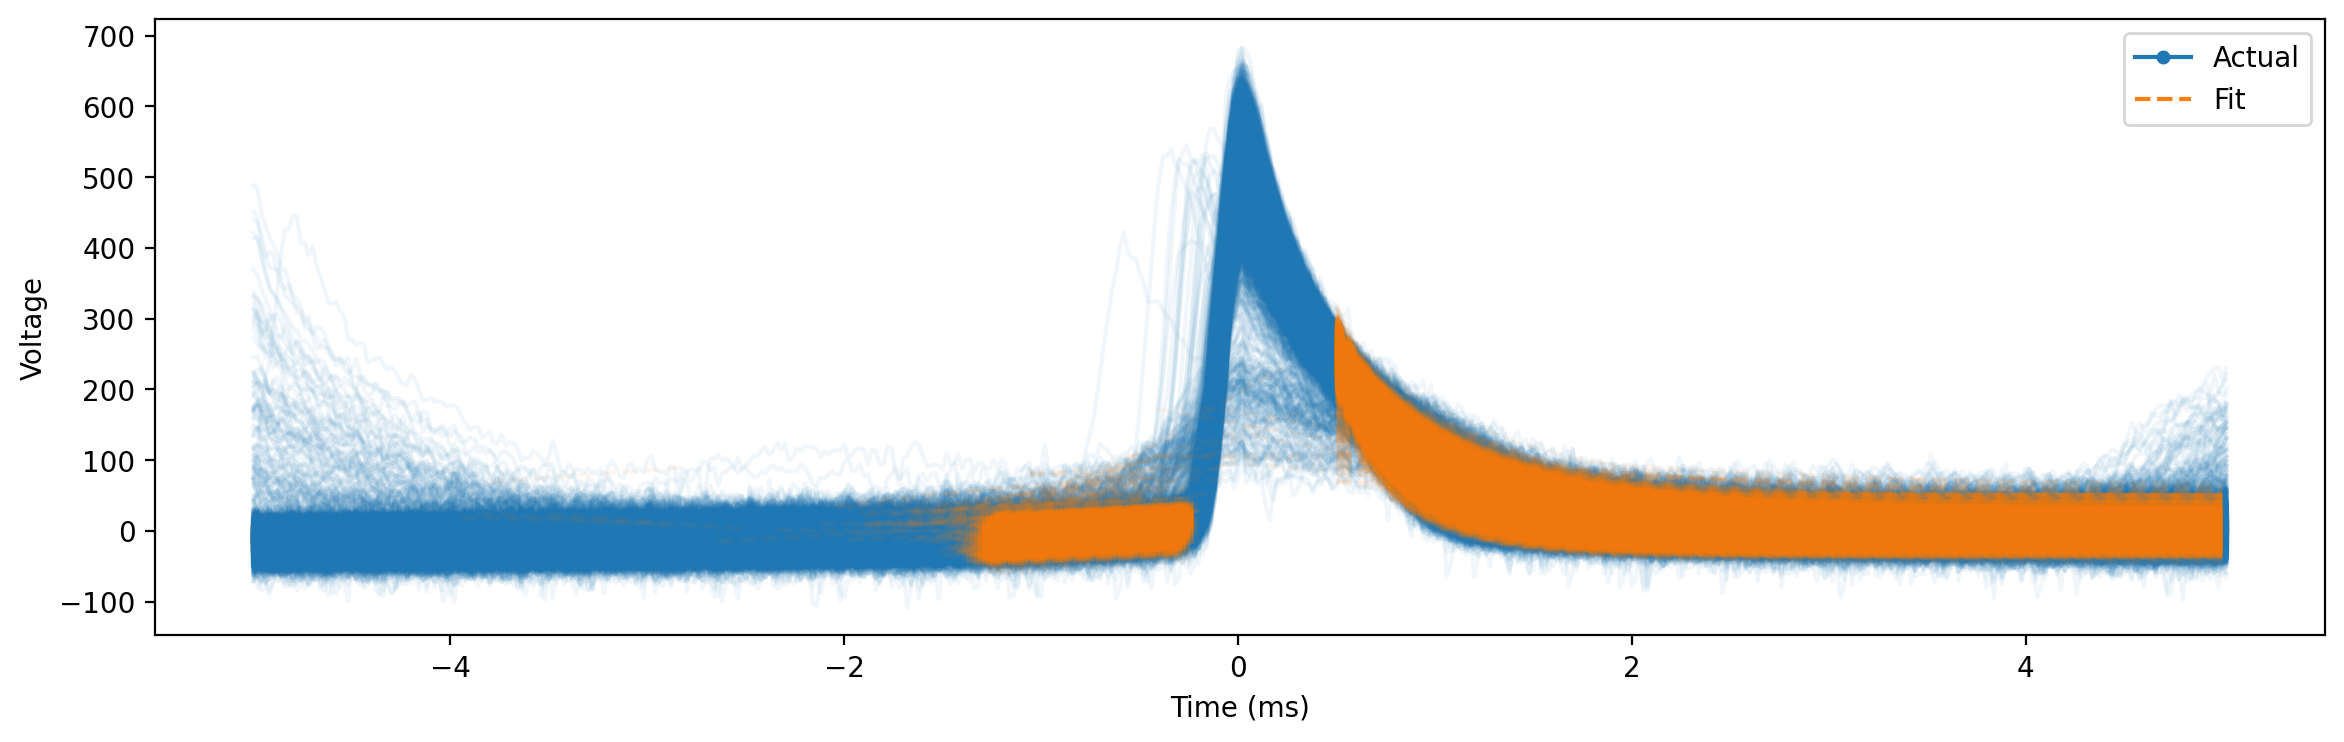

In [10]:
sp.plot()

### Filter spikes 

In [11]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [12]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [13]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,10.961881,0.30,18.382591,395.951470,0.62,79.815607,3.948223,-7.969183,2.013977,21998,4.397498e+02,0
1,11.199292,0.30,25.167280,410.769554,0.58,38.602095,3.252343,10.962803,2.176694,27164,5.430205e+02,1
2,18.679989,0.26,-16.844094,380.923194,0.66,104.931446,2.765642,-9.252601,1.491714,34678,6.932287e+02,2
3,27.569685,0.36,24.323961,386.861926,0.68,51.947039,2.844248,16.399738,2.982055,36230,7.242538e+02,3
4,11.695808,0.30,7.862321,412.076375,0.50,73.183001,5.008926,-3.030722,2.366962,84229,1.683775e+03,4
...,...,...,...,...,...,...,...,...,...,...,...,...
4496,10.949018,0.22,30.747441,500.183396,0.56,171.615948,1.280002,2.863477,2.762231,53960086,1.078686e+06,3792
4497,16.978693,0.22,25.482944,635.452971,0.44,254.095983,2.919569,-6.782038,1.301257,53989020,1.079265e+06,3793
4498,16.588751,0.24,33.900754,592.427963,0.46,217.024450,1.659293,15.158946,1.830894,53990021,1.079285e+06,3794
4501,21.334151,0.24,34.382807,642.778547,0.46,256.968232,1.976378,15.565057,1.705998,54001877,1.079522e+06,3795


### Get spike times


In [14]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 2: Cluster ISI spike groups 

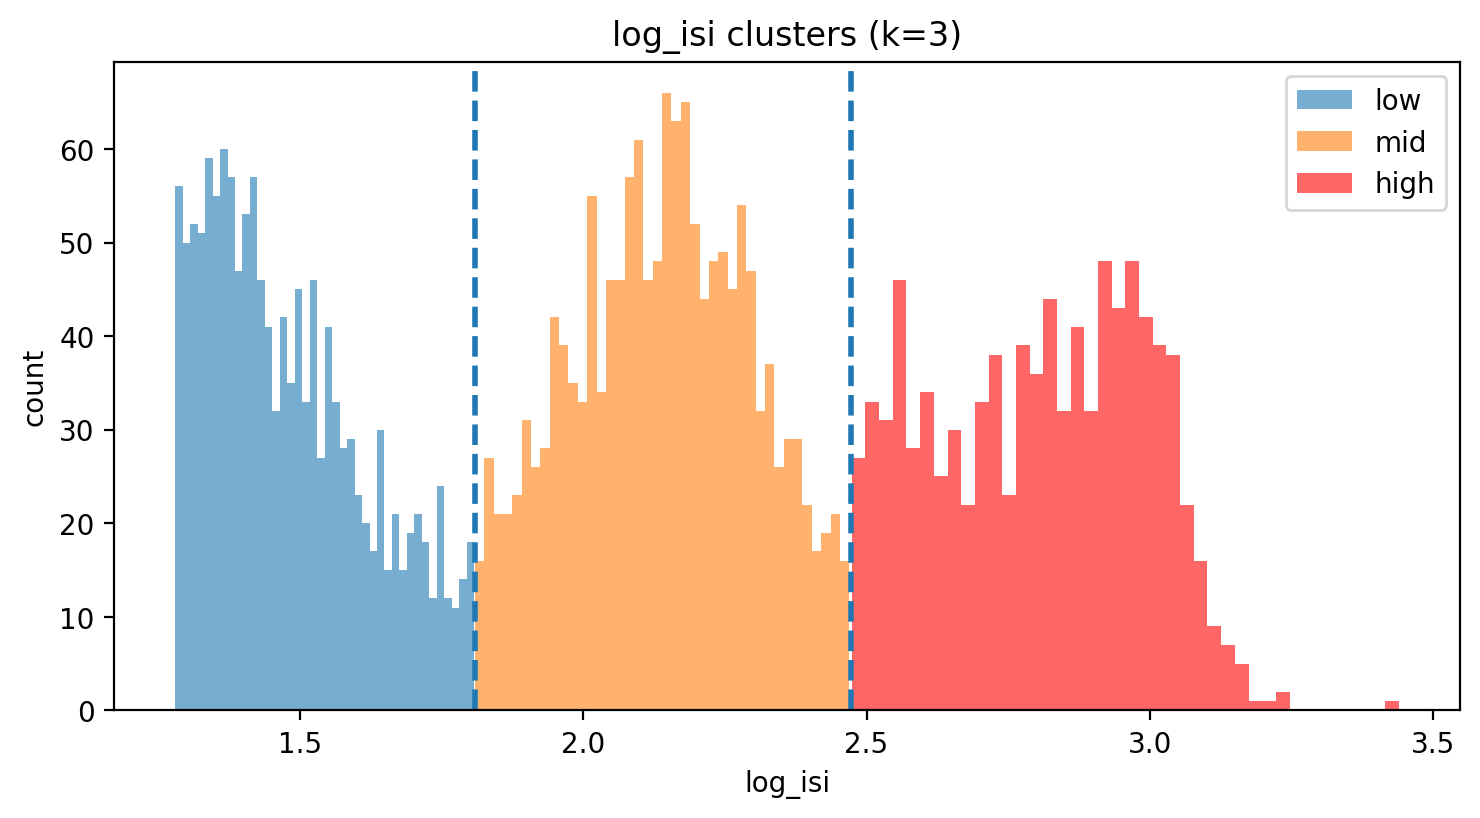

In [15]:
# scan all numeric features and only cluster the ones that look multimodal
df_features_clust, rep = cluster_multimodal_features(
    df_features,
    max_k=3,
    suffix="_cluster",
    plot_each=True  # set True if you want a quick plot per clustered feature
)







In [16]:
df_features_clust

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id,log_isi_cluster
0,10.961881,0.30,18.382591,395.951470,0.62,79.815607,3.948223,-7.969183,2.013977,21998,4.397498e+02,0,mid
1,11.199292,0.30,25.167280,410.769554,0.58,38.602095,3.252343,10.962803,2.176694,27164,5.430205e+02,1,mid
2,18.679989,0.26,-16.844094,380.923194,0.66,104.931446,2.765642,-9.252601,1.491714,34678,6.932287e+02,2,low
3,27.569685,0.36,24.323961,386.861926,0.68,51.947039,2.844248,16.399738,2.982055,36230,7.242538e+02,3,high
4,11.695808,0.30,7.862321,412.076375,0.50,73.183001,5.008926,-3.030722,2.366962,84229,1.683775e+03,4,mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4496,10.949018,0.22,30.747441,500.183396,0.56,171.615948,1.280002,2.863477,2.762231,53960086,1.078686e+06,3792,high
4497,16.978693,0.22,25.482944,635.452971,0.44,254.095983,2.919569,-6.782038,1.301257,53989020,1.079265e+06,3793,low
4498,16.588751,0.24,33.900754,592.427963,0.46,217.024450,1.659293,15.158946,1.830894,53990021,1.079285e+06,3794,mid
4501,21.334151,0.24,34.382807,642.778547,0.46,256.968232,1.976378,15.565057,1.705998,54001877,1.079522e+06,3795,low


### STETP 3: Separate spikes into short ISIs and long ISIs and find transition points (long ISI spikes to group of short ISI spikes)

#### Visualize ISI spike cluster groups over time 

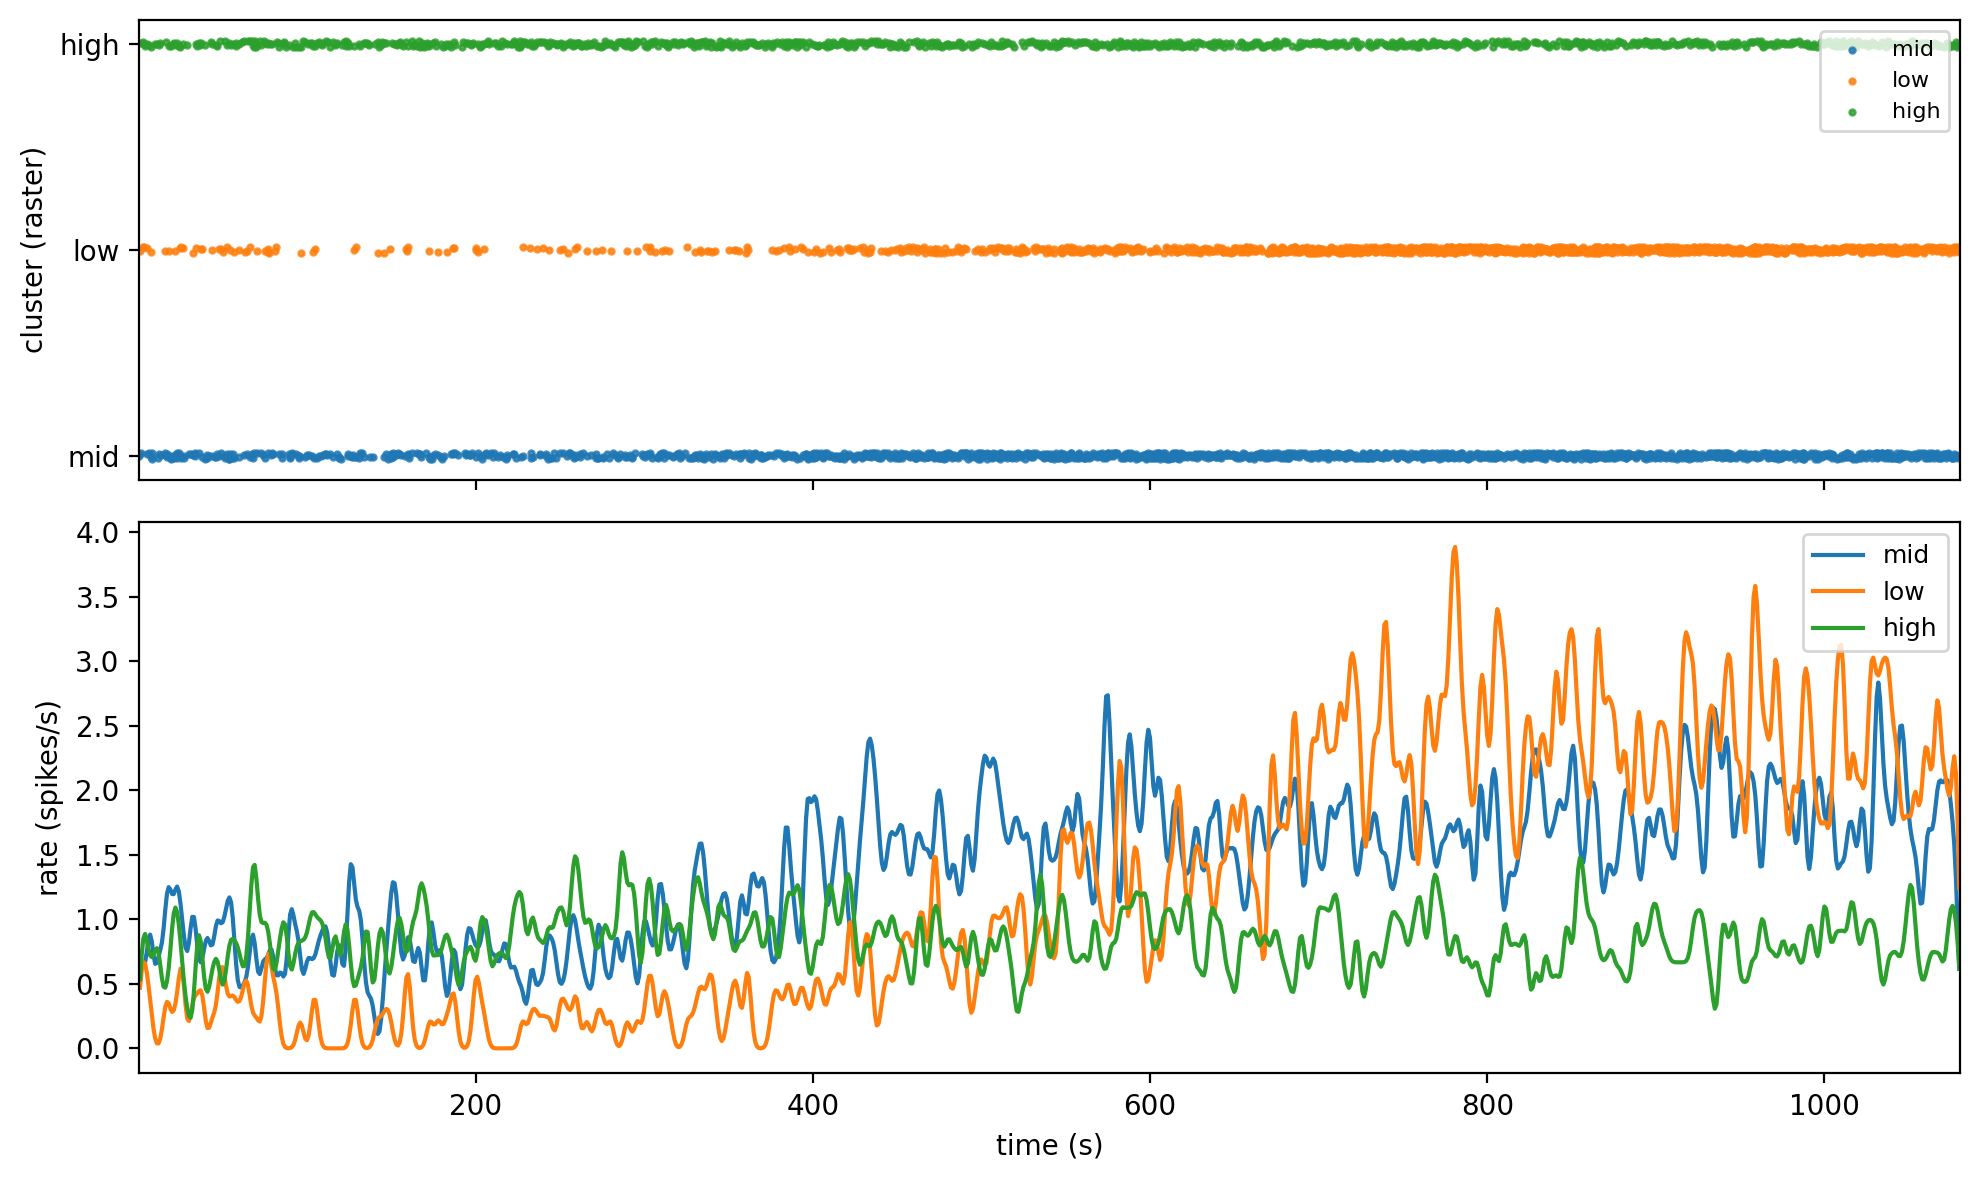

In [17]:
plot_clusters_over_time_min(
    df_features_clust,
    time_col="spk_times_ms",
    label_col="log_isi_cluster",   
    time_unit="ms",
    bin_size_ms=1000,
    sigma_bins=2
)


#### Calculate transition probabilities 

          high       low       mid
high  0.172678  0.432787  0.394536
low   0.265934  0.230037  0.504029
mid   0.260554  0.432058  0.307388


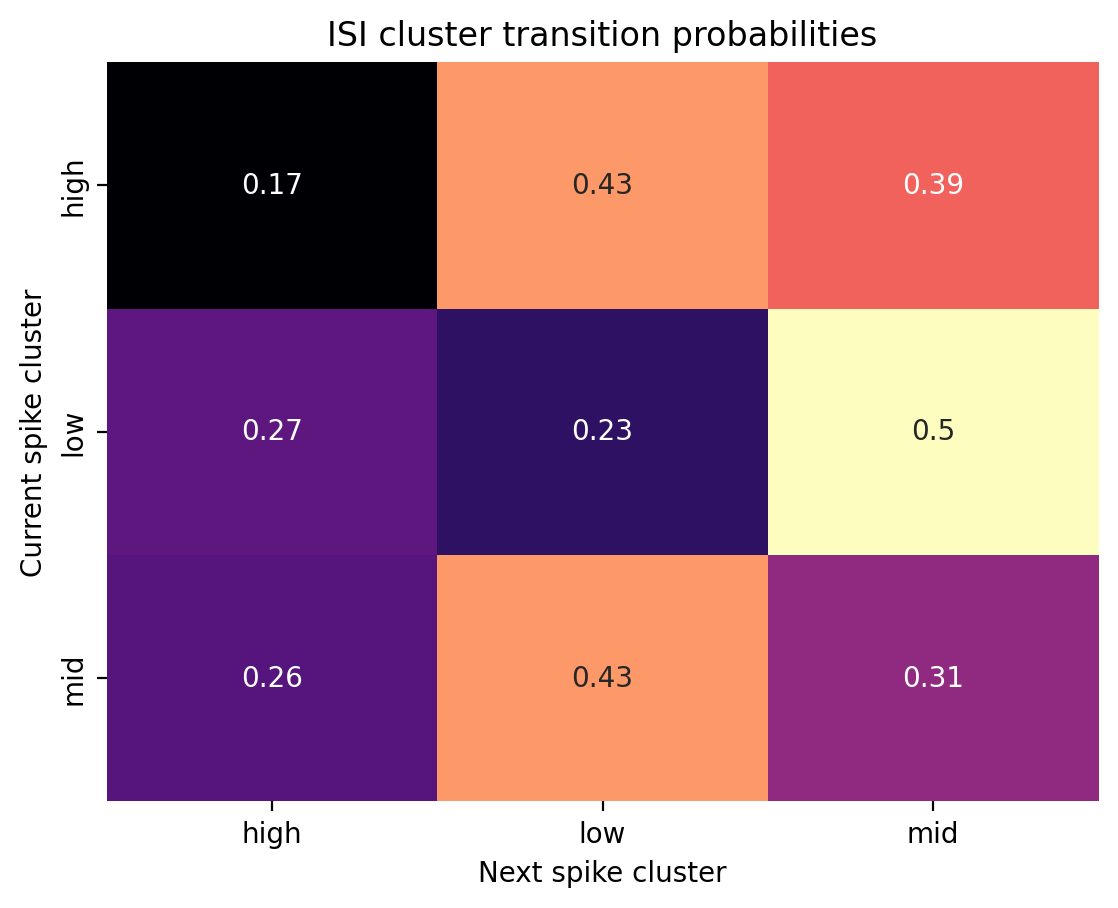

In [18]:
trans_mat = cluster_transition_matrix(df_features_clust, "log_isi_cluster")
print(trans_mat)

sns.heatmap(trans_mat, annot=True, cmap="magma", cbar=False)
plt.title("ISI cluster transition probabilities")
plt.xlabel("Next spike cluster")
plt.ylabel("Current spike cluster")
plt.show()


#### Find transition points 

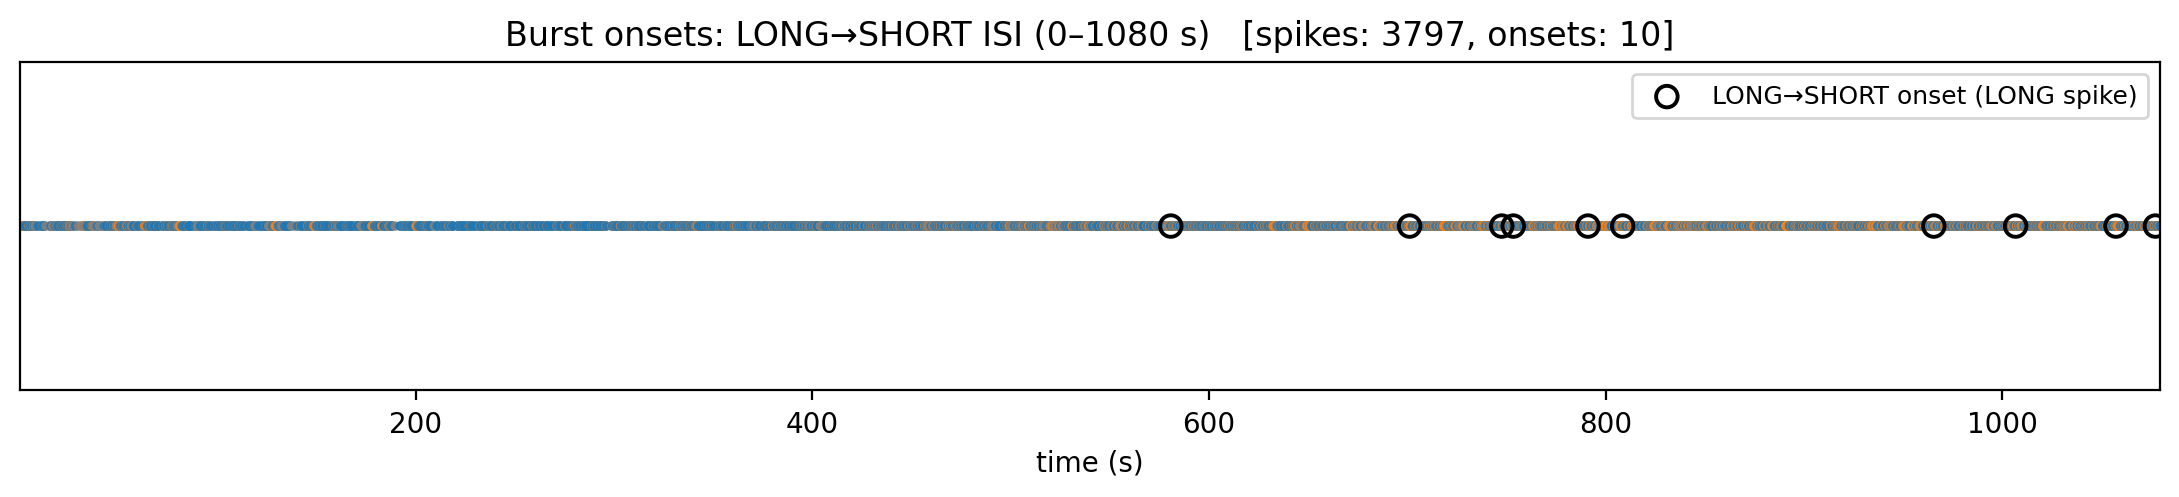

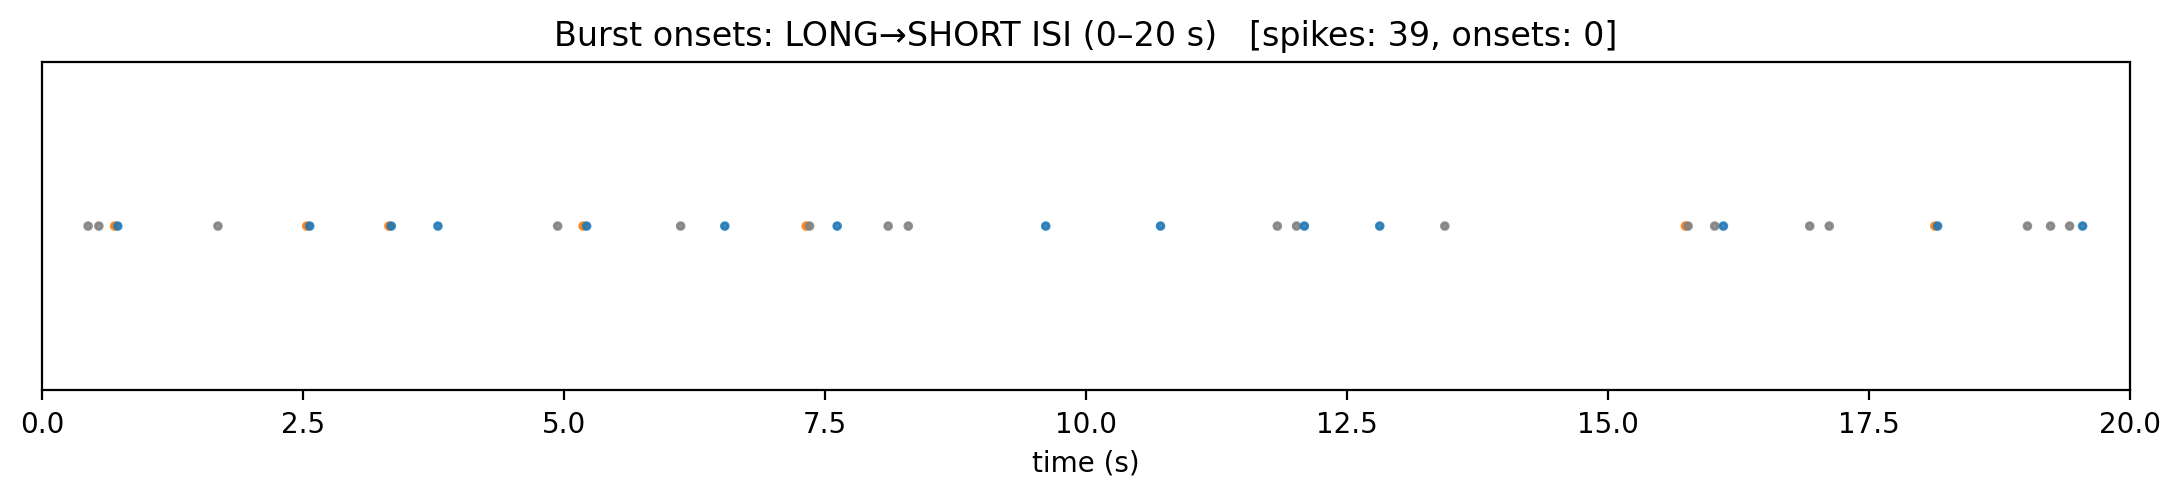

In [19]:
# Identify high spikes that start low bursts
df_marked = mark_high_burst_onsets(
    df_features_clust,
    cluster_col="log_isi_cluster",
    time_col="spk_times_ms",
    min_low_run=3  # how many LOW spikes must follow to count as a burst
)

# Plot full timeline
plot_long_to_short_isi_onsets(
    df_marked,
    time_col="spk_times_ms",
    cluster_col="log_isi_cluster"          

)


# Zoom into a specific range 
plot_long_to_short_isi_onsets(
    df_marked,
    time_col="spk_times_ms",
    cluster_col="log_isi_cluster",
    time_range=(00, 20)  # seconds
)


In [20]:
df_marked

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id,log_isi_cluster,is_long_to_short_isi_onset
0,10.961881,0.30,18.382591,395.951470,0.62,79.815607,3.948223,-7.969183,2.013977,21998,4.397498e+02,0,mid,False
1,11.199292,0.30,25.167280,410.769554,0.58,38.602095,3.252343,10.962803,2.176694,27164,5.430205e+02,1,mid,False
2,18.679989,0.26,-16.844094,380.923194,0.66,104.931446,2.765642,-9.252601,1.491714,34678,6.932287e+02,2,low,False
3,27.569685,0.36,24.323961,386.861926,0.68,51.947039,2.844248,16.399738,2.982055,36230,7.242538e+02,3,high,False
4,11.695808,0.30,7.862321,412.076375,0.50,73.183001,5.008926,-3.030722,2.366962,84229,1.683775e+03,4,mid,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3792,10.949018,0.22,30.747441,500.183396,0.56,171.615948,1.280002,2.863477,2.762231,53960086,1.078686e+06,3792,high,False
3793,16.978693,0.22,25.482944,635.452971,0.44,254.095983,2.919569,-6.782038,1.301257,53989020,1.079265e+06,3793,low,False
3794,16.588751,0.24,33.900754,592.427963,0.46,217.024450,1.659293,15.158946,1.830894,53990021,1.079285e+06,3794,mid,False
3795,21.334151,0.24,34.382807,642.778547,0.46,256.968232,1.976378,15.565057,1.705998,54001877,1.079522e+06,3795,low,False


#### Look at the other waveform features for the "transition" spikes
There are no significant differences in the waveform features forr the transition spikes vs other spikes


Comparing groups: True (transition spike ) vs False (non-transition spike ) using column 'is_long_to_short_isi_onset'

peak_width          : t-test        (p=0.0420)
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


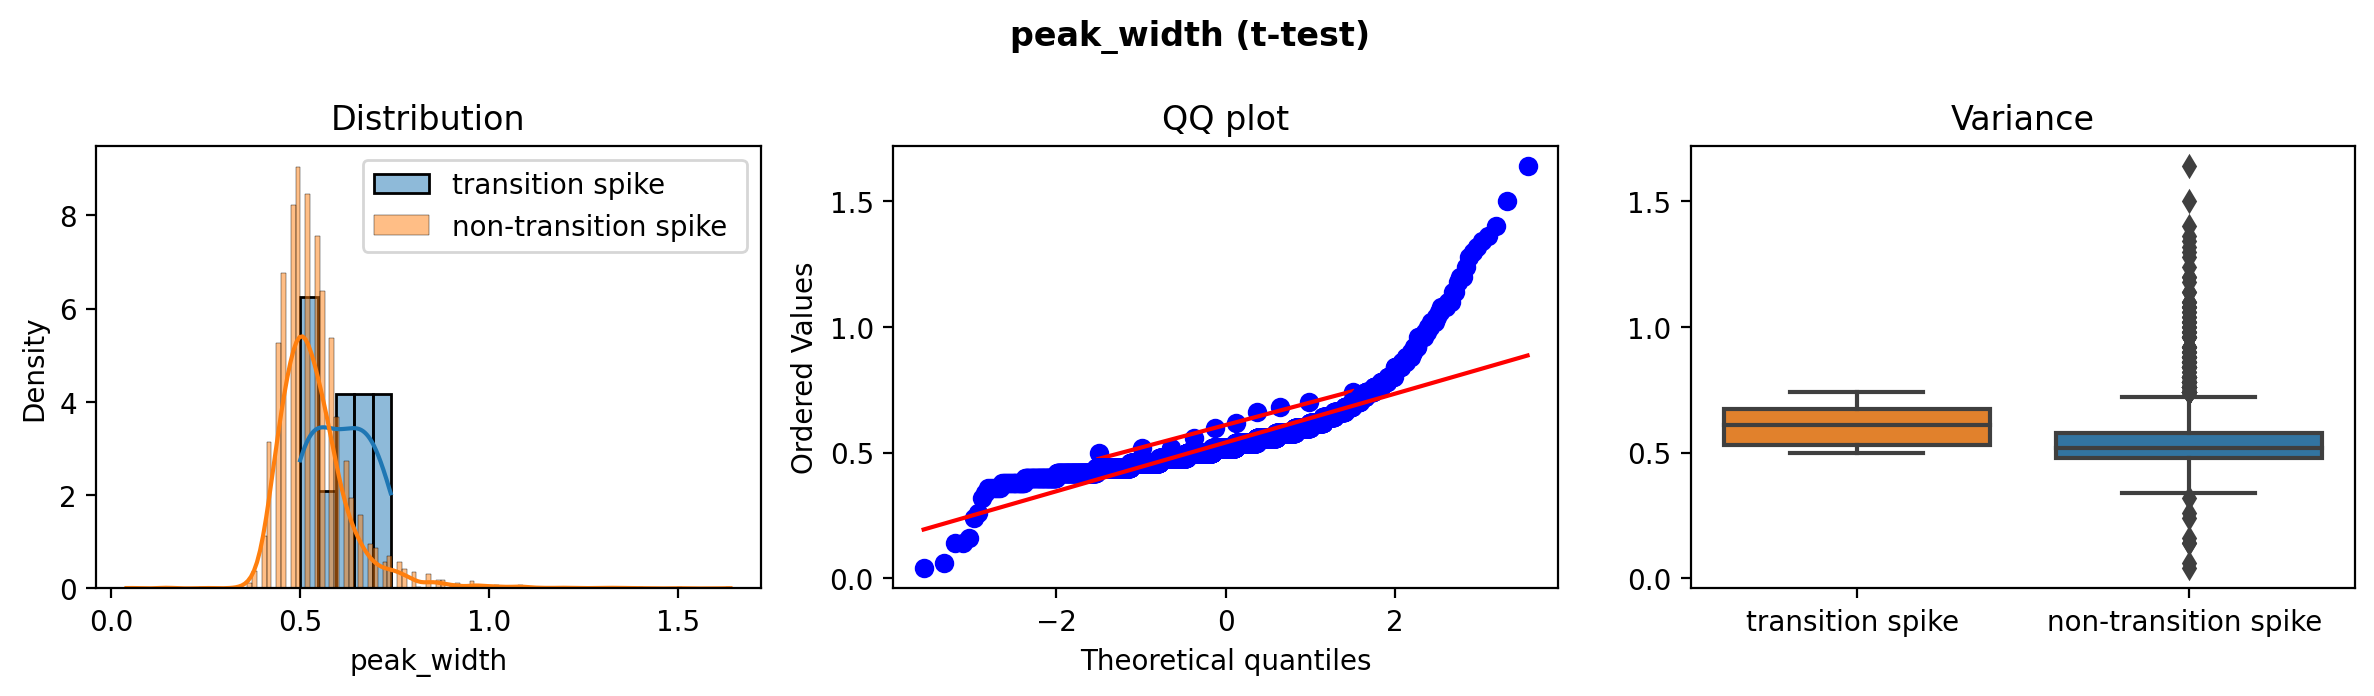

ramp_amp            : t-test        (p=0.9504)


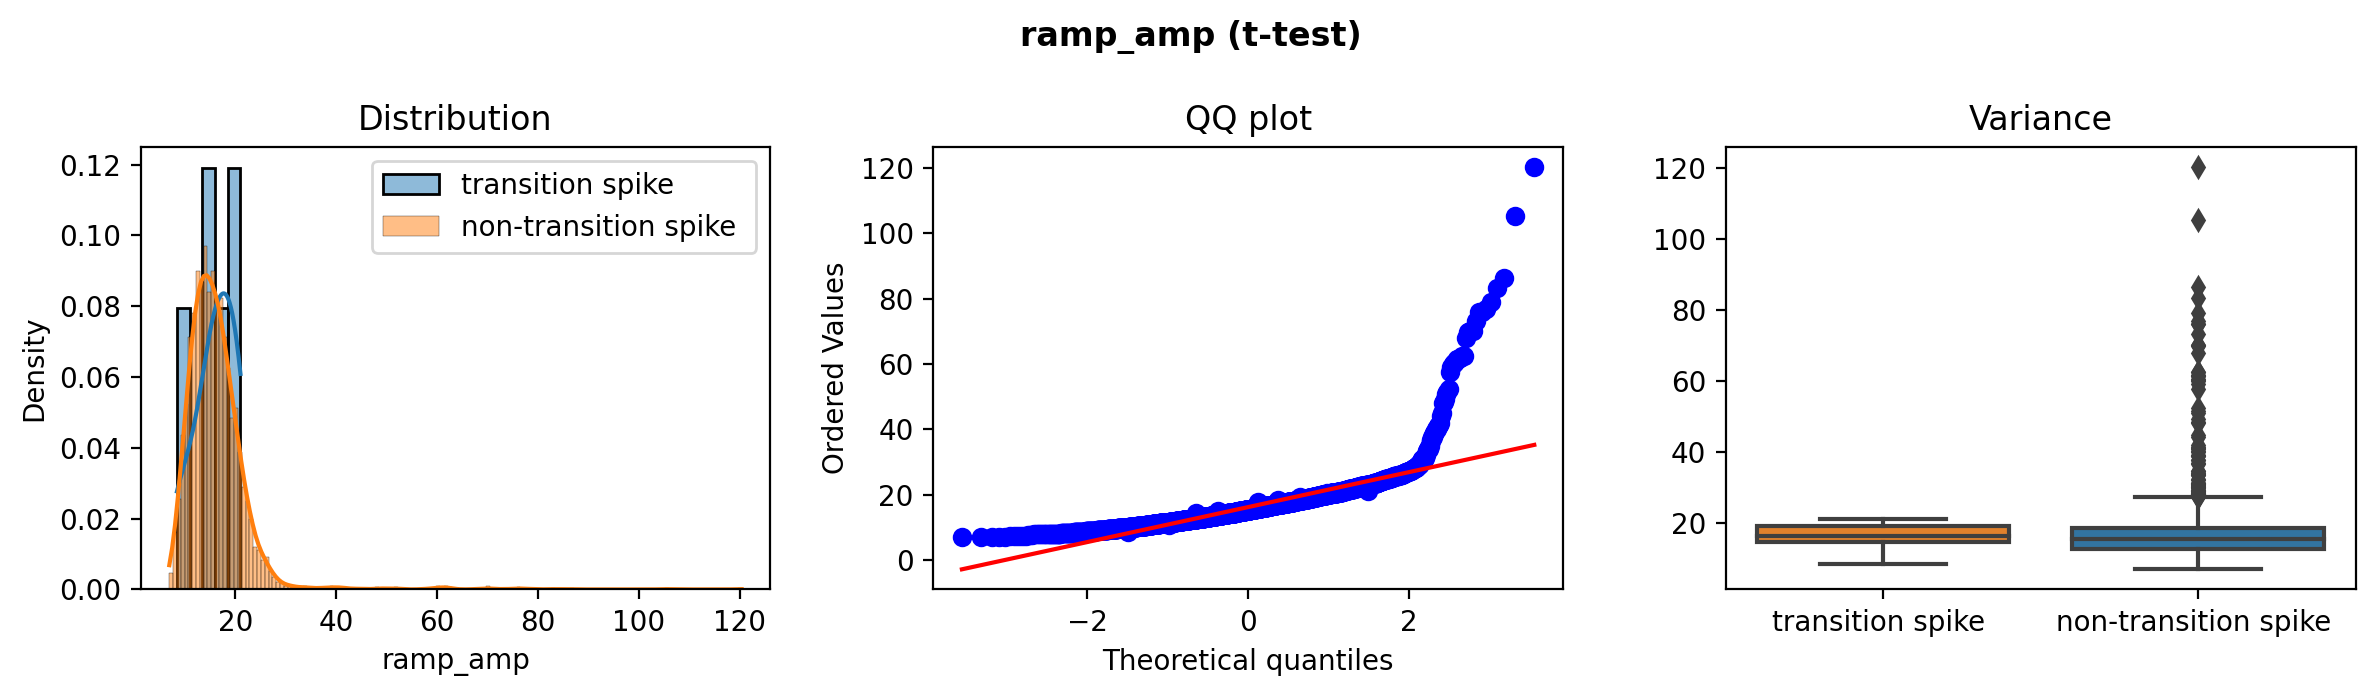

peak_sharpness      : t-test        (p=0.1659)


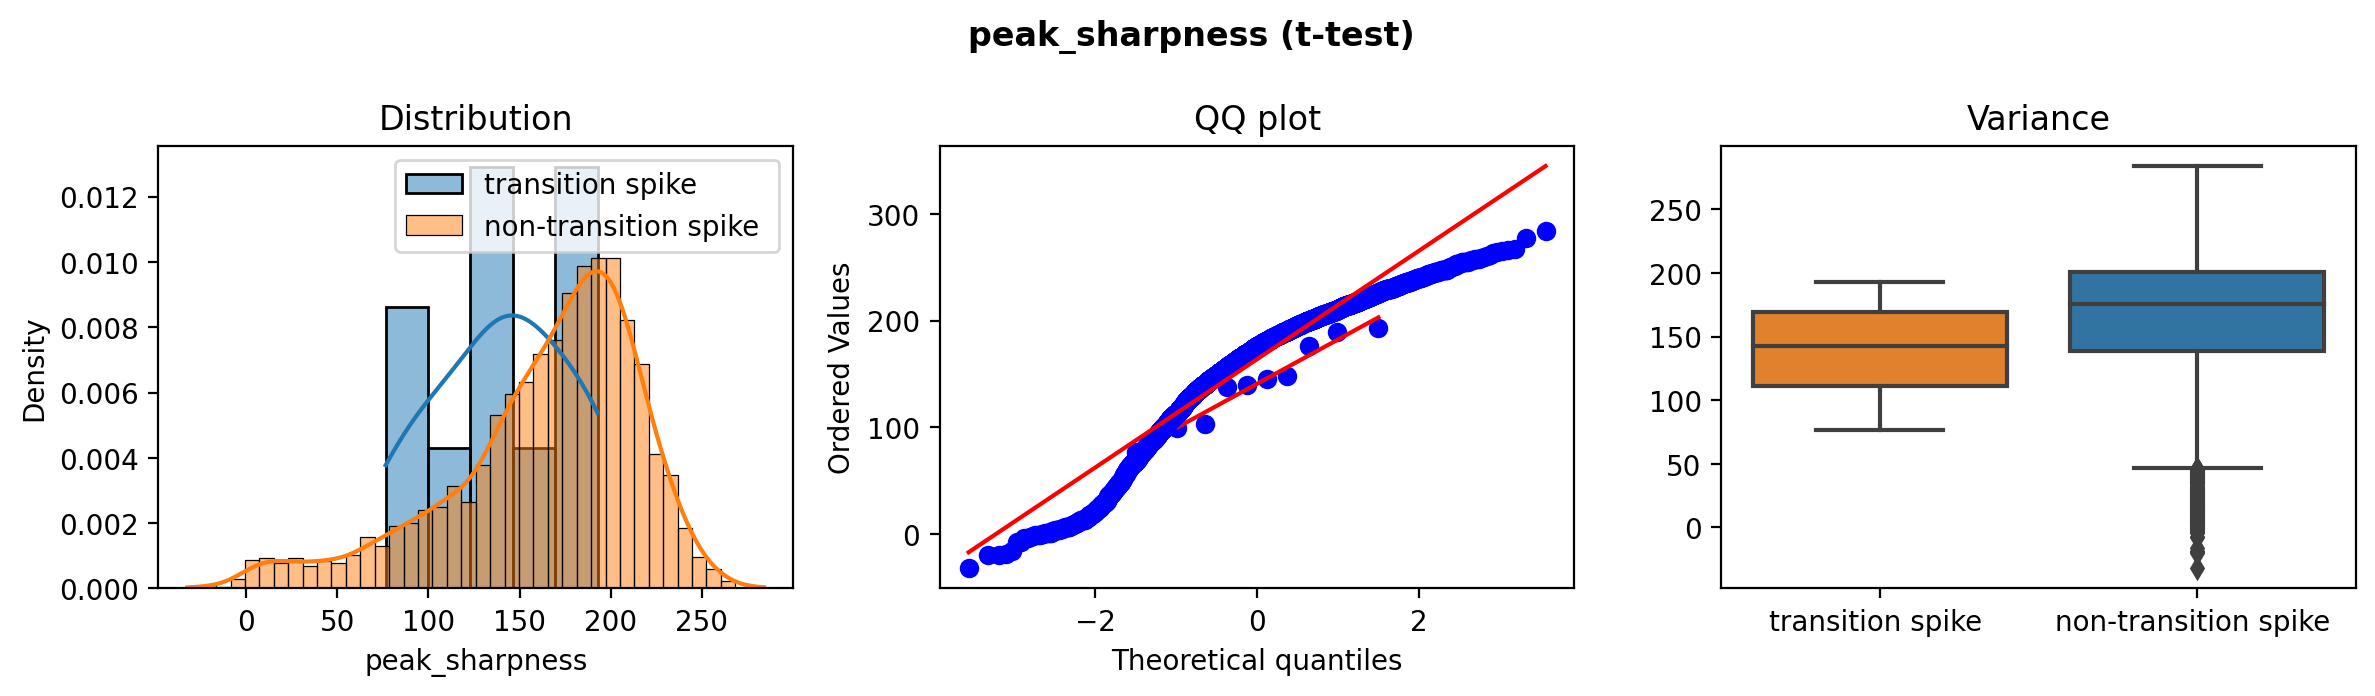

inflection_amp      : t-test        (p=0.0002)


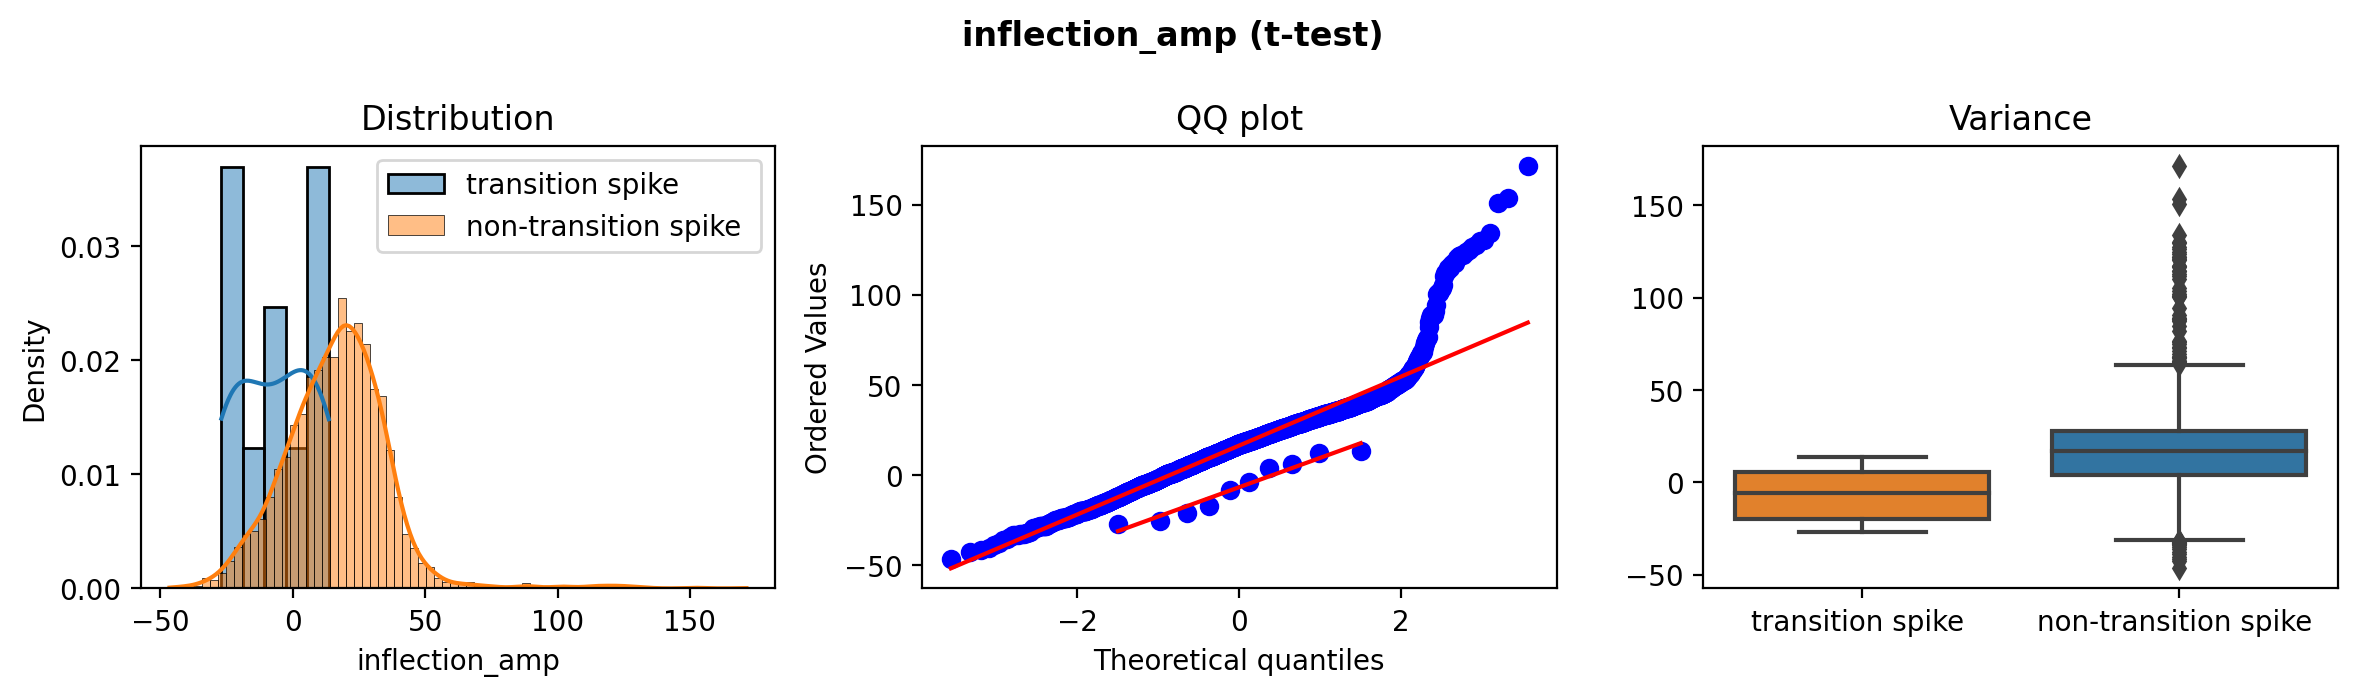

exp_lambda          : t-test        (p=0.0204)


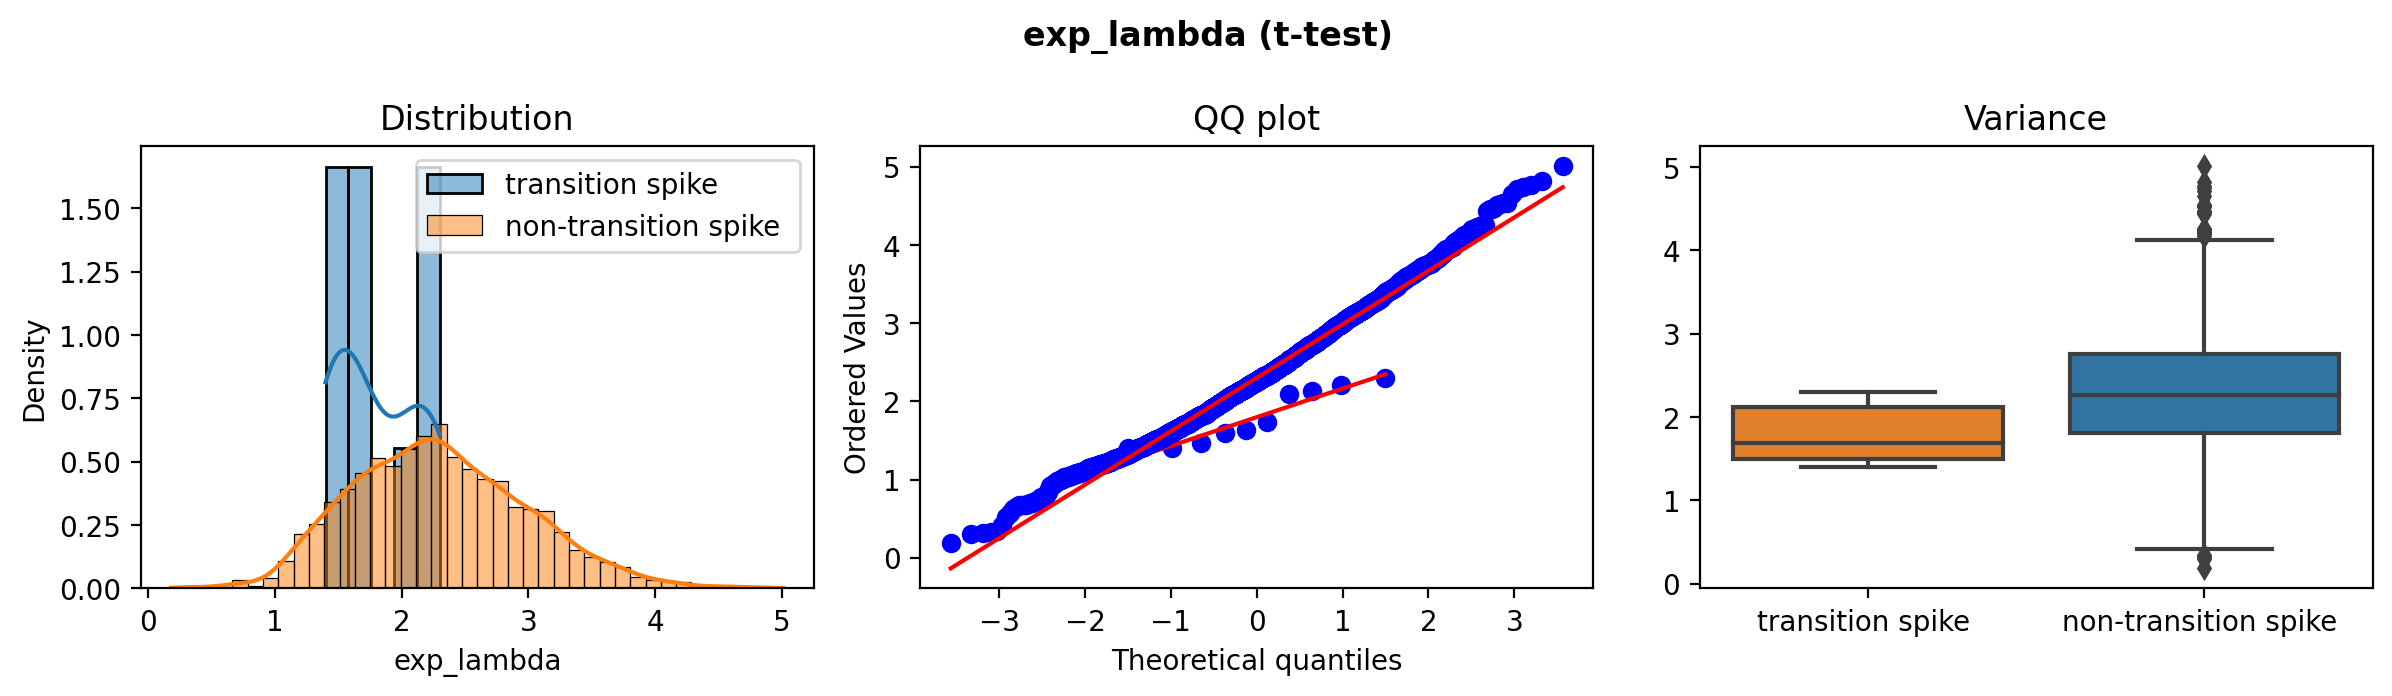

In [21]:

res = compare_feature_groups(
    df_marked,
    features= ["peak_width","ramp_amp","peak_sharpness", "inflection_amp", "exp_lambda"],
    group_col="is_long_to_short_isi_onset",
    groups=(True, False),              
    group_names=("transition spike ","non-transition spike "),  
    show_plots=True
)




In [22]:
#also look at long ISI vs short ISI

features = ["ramp_amp", "peak_width", "peak_sharpness", "inflection_amp", "exp_lambda"]

compare_feature_groups(
    df_features_clust,
    features= features,
    group_col="log_isi_cluster",
    groups=("high", "low", "medium"),              # which two cluster labels to compare
    group_names=("long ISI", "short ISI", "medium ISI"),    # names for plot labels
    show_plots=True
)



ValueError: too many values to unpack (expected 2)

## LOOK AT PEAK WIDTH CLUSTERS
#### What do the feature distributions look like for the peak width clusters?

For the peak width groups the other spike feature also follow the same groupping/clustering, except for ISI 

In [ ]:
plot_clusters_over_time_min(
    df_features_clust,
    time_col="spk_times_ms",
    label_col="peak_width_cluster",   
    time_unit="ms",
    bin_size_ms=1000,
    sigma_bins=2
)


In [ ]:
trans_mat_peak_width = cluster_transition_matrix(df_features_clust, "log_isi_cluster")
print(trans_mat_peak_width)

sns.heatmap(trans_mat_peak_width, annot=True, cmap="magma", cbar=False)
plt.title("Peak width cluster transition probabilities")
plt.xlabel("Next spike cluster")
plt.ylabel("Current spike cluster")
plt.show()

In [ ]:
results_pw = compare_feature_groups(
    df_features_clust,
    features= ["ramp_amp","peak_sharpness", "inflection_amp", "exp_lambda", "log_isi"],
    group_col="peak_width_cluster",
    groups=("high", "low"),              # which two cluster labels to compare
    group_names=("wide peak","narrow peak"),    # names for plot labels
    show_plots=True
)

results_pw


### STEP 4: Analyze LFP around spikes

### 1) Extract LFP windows and visualize 

In [ ]:
df_marked

In [ ]:
#get transition spike LFP windows 

transition_spike_extractor = extract_lfp_windows(
    spk_df=df_marked,
    lfp_times_ms=lfp_times,
    lfp_signal=lfp_filt,
    pre_s=1.0,
    post_s=1.5, 
    condition="is_long_to_short_isi_onset"

)

windows_transition = transition_spike_extractor["windows"]
t_rel_transitions = transition_spike_extractor["times_rel_ms"]
spike_times_transition = transition_spike_extractor["spike_times_ms"]
next_spk_times_transition = transition_spike_extractor["next_spike_times_ms"]
meta_df_transitions = transition_spike_extractor["meta_df"]

#get control  spike LFP windows 

ctrl_spike_extractor = extract_lfp_windows(
    spk_df=df_marked,
    lfp_times_ms=lfp_times,
    lfp_signal=lfp_filt,
    pre_s=1.0,
    post_s=1.5, 
    condition="is_long_to_short_isi_onset == False"

)

windows_ctrl = ctrl_spike_extractor["windows"]
t_rel_ctrl = ctrl_spike_extractor["times_rel_ms"]
spike_times_ctrl = ctrl_spike_extractor["spike_times_ms"]
next_spk_times_ctrl = ctrl_spike_extractor["next_spike_times_ms"]
meta_df_ctrl = ctrl_spike_extractor["meta_df"]


#get long ISI spikes windows
longISI_spike_extractor = extract_lfp_windows(
    spk_df=df_marked,
    lfp_times_ms=lfp_times,
    lfp_signal=lfp_filt,
    pre_s=1.0,
    post_s=1.5, 
    condition="log_isi_cluster == 'high'"

)

windows_longISI = longISI_spike_extractor["windows"]
t_rel_longISI = longISI_spike_extractor["times_rel_ms"]
spike_times_longISI = longISI_spike_extractor["spike_times_ms"]
next_spk_times_longISI = longISI_spike_extractor["next_spike_times_ms"]
meta_df_longISI = longISI_spike_extractor["meta_df"]


#get short ISI spikes windows
shortISI_spike_extractor = extract_lfp_windows(
    spk_df=df_marked,
    lfp_times_ms=lfp_times,
    lfp_signal=lfp_filt,
    pre_s=1.0,
    post_s=1.5, 
    condition="log_isi_cluster == 'low'"

)

windows_shortISI = shortISI_spike_extractor["windows"]
t_rel_shortISI = shortISI_spike_extractor["times_rel_ms"]
spike_times_shortISI = shortISI_spike_extractor["spike_times_ms"]
next_spk_times_shortISI = shortISI_spike_extractor["next_spike_times_ms"]
meta_df_shortISI = shortISI_spike_extractor["meta_df"]

#get wide peak spike windows
widepeak_spike_extractor = extract_lfp_windows(
    spk_df=df_marked,
    lfp_times_ms=lfp_times,
    lfp_signal=lfp_filt,
    pre_s=1.0,
    post_s=1.5, 
    condition="peak_width_cluster == 'high'"

)

windows_widepeak = widepeak_spike_extractor["windows"]
t_rel_widepeak = widepeak_spike_extractor["times_rel_ms"]
spike_times_widepeak = widepeak_spike_extractor["spike_times_ms"]
next_spk_times_widepeak = widepeak_spike_extractor["next_spike_times_ms"]
meta_df_widepeak =widepeak_spike_extractor["meta_df"]

#get narrow peak spike windows 
narrpeak_spike_extractor = extract_lfp_windows(
    spk_df=df_marked,
    lfp_times_ms=lfp_times,
    lfp_signal=lfp_filt,
    pre_s=1.0,
    post_s=1.5, 
    condition="peak_width_cluster == 'low'"

)

windows_narrpeak = narrpeak_spike_extractor["windows"]
t_rel_narrpeak = narrpeak_spike_extractor["times_rel_ms"]
spike_times_narrpeak = narrpeak_spike_extractor["spike_times_ms"]
next_spk_times_narrpeak = narrpeak_spike_extractor["next_spike_times_ms"]
meta_df_narrpeak =narrpeak_spike_extractor["meta_df"]

In [ ]:
#Plot LFP heatmap

next_rel_trans = (
    np.asarray(next_spk_times_transition, dtype=float)
    - np.asarray(spike_times_transition, dtype=float)
) 

next_rel_ctrl = (
    np.asarray(next_spk_times_ctrl, dtype=float)
    - np.asarray(spike_times_ctrl, dtype=float)
) 

next_rel_longISI = (
    np.asarray(next_spk_times_longISI, dtype=float)
    - np.asarray(spike_times_longISI, dtype=float)
) 

next_rel_shortISI = (
    np.asarray(next_spk_times_shortISI, dtype=float)
    - np.asarray(spike_times_shortISI, dtype=float)
) 

next_rel_widepeak = (
    np.asarray(next_spk_times_widepeak, dtype=float)
    - np.asarray(spike_times_widepeak, dtype=float)
) 

next_rel_narrpeak = (
    np.asarray(next_spk_times_narrpeak, dtype=float)
    - np.asarray(spike_times_narrpeak, dtype=float)
) 

groups = {
    "Transition spikes (LFP)": {
        "windows":   windows_transition,   # list of LFP traces
        "times_rel": t_rel_transitions,
        "next_rel":  next_rel_trans,
    },
    "Control spikes (LFP)": {
        "windows":   windows_ctrl,
        "times_rel": t_rel_ctrl,
        "next_rel":  next_rel_ctrl,
    },
    "Long ISI spikes (LFP)": {
        "windows":   windows_longISI,
        "times_rel": t_rel_longISI,
        "next_rel":  next_rel_longISI,
    },
    "Short ISI spikes (LFP)": {
        "windows":   windows_shortISI,
        "times_rel": t_rel_shortISI,
        "next_rel":  next_rel_shortISI,
    },
    "Wide spikes (LFP)": {
        "windows":   windows_widepeak,
        "times_rel": t_rel_widepeak,
        "next_rel":  next_rel_widepeak,
    },
    "Narrow spikes (LFP)": {
        "windows":   windows_narrpeak,
        "times_rel": t_rel_narrpeak,
        "next_rel":  next_rel_narrpeak,
    },
    
}

lfp_heatmaps = plot_window_feature_groups_heatmap(
    groups,
    feature_label="LFP (µV)",
    cmap="viridis",
    time_unit="ms",
)


In [ ]:
#plot mean LFP aprpind spike 
fig, ax, out_traces = plot_window_feature_group_traces(
    groups,
    time_unit="ms",             # if your t_rel_* are already in seconds
    ylabel="LFP (µV)",
    title="Average LFP around spikes (all groups)",
    band_k=1.0,                # 1×STD band
)


### 2) Run time resolved specparam on windows 

In [ ]:
"""time_res_results = run_time_resolved_specparam_for_groups(
    groups,
    fs=lfp_fs,
    inner_window_sec=0.5,
    freq_range=(4, 90),
    n_freqs=256,
    time_bandwidth=2.0,
    decim_factor=10,
    aperiodic_mode="fixed",     
    max_windows_per_group=None,     # or None for all
)
"""

In [ ]:
"""with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c14/specp_cluster.pkl', 'wb') as file:
    pickle.dump(time_res_results, file)"""

In [ ]:
#open pickle
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/multitaper_pickles/c14/specp_cluster.pkl', 'rb') as file:
    time_res_results = pickle.load(file)

In [ ]:
#trim edges
time_res_results = trim_edges(time_res_results, edge_sec=0.5)

### 3) Visualize specparam results (heatmap, traces, and aperiodic vs raw spctrum plots 

In [ ]:
my_colors = {
    "Transition spikes (LFP)": "#1f77b4",
    "Control spikes (LFP)":    "#ff7f0e",
    "Long ISI spikes (LFP)":   "#2ca02c",
    "Short ISI spikes (LFP)":  "#d61428",
    "Wide spikes (LFP)":       "brown",
    "Narrow spikes (LFP)":     "darkgreen",
}



In [ ]:
exp_groups = make_feature_groups(time_res_results, feature="exponent")

for gname in exp_groups.keys():
    exp_groups[gname]["color"] = my_colors[gname]

results_exp = plot_window_feature_groups_heatmap(
    exp_groups,
    feature_label="Exponent",
    cmap="viridis",
    time_unit="s",
)



In [ ]:
gamma_groups = make_feature_groups(time_res_results, "band", band="gamma")
for gname in gamma_groups.keys():
    gamma_groups[gname]["color"] = my_colors[gname]
results_gamma = plot_window_feature_groups_heatmap(
    gamma_groups,
    feature_label="AUC gamma",
    cmap="viridis",
    time_unit="s",
)


In [ ]:
fig, ax, out_traces = plot_window_feature_group_traces(
    exp_groups,
    time_unit="s",   # exponent timeline is in seconds now
    ylabel="Aperiodic exponent",
    title="Average exponent around spikes (time-resolved specparam)",
    band_k=0.5, tmin = -0.5
)


In [ ]:
fig, ax, out_traces = plot_window_feature_group_traces(
    gamma_groups,
    time_unit="s",   # exponent timeline is in seconds now
    ylabel="AUC gamma",
    title="Average AUC gamma around spikes (time-resolved specparam)",
    band_k=0.5, tmin = -0.5
)


In [ ]:
group_name = "Transition spikes (LFP)"
window_i   = 59
epoch_i    = 10   # or whichever time bin you want

res = time_res_results[group_name][window_i]

fig, ax, auc = plot_aperiodic_fit_with_band_auc(
    freqs   = res["freqs"],
    powers  = res["powers"],   # (n_epochs, n_freqs), linear
    time_model = res["model"], # SpectralTimeModel
    epoch_i = epoch_i,
    band_range = (30, 55),     # gamma
    title = f"{group_name} | window {window_i} | epoch {epoch_i}",
)



### 4) Further analyze specparam results

In [ ]:
# exponent groups already made earlier:
# exp_groups = make_feature_groups(time_res_results, feature="exponent")

window = (-0.2, 0.0)  # -200 ms to spike; times_rel is in seconds

stats_res = boxplot_feature_window_stats(
    exp_groups,
    window=window,
    reducer="mean",
    feature_label="Exponent",
    time_unit="s",   # 
)

print(stats_res)


In [ ]:
# exponent groups already made earlier:
# exp_groups = make_feature_groups(time_res_results, feature="exponent")

window = (-0.2, 0.0)  # -200 ms to spike; times_rel is in seconds

stats_res = boxplot_feature_window_stats(
    gamma_groups,
    window=window,
    reducer="mean",
    feature_label="auc gamma",
    time_unit="s",   # 
)

print(stats_res)


### 4) Compare transition spikes vs control

In [ ]:
#make only transition vs control dict
trans_ctrl_keys = ['Transition spikes (LFP)', 'Control spikes (LFP)']
trans_ctrl_exp_groups = {key: exp_groups[key] for key in trans_ctrl_keys if key in exp_groups}
trans_ctrl_gamma_groups = {key: gamma_groups[key] for key in trans_ctrl_keys if key in gamma_groups}



In [ ]:
fig, ax, out_traces = plot_window_feature_group_traces(
    trans_ctrl_exp_groups,
    time_unit="s",   # exponent timeline is in seconds now
    ylabel="Aperiodic exponent",
    title="Average exponent around spikes (time-resolved specparam)",
    band_k=0.5, tmin = -0.5, tmax = 2
)


In [ ]:
fig, ax, out_traces = plot_window_feature_group_traces(
    trans_ctrl_gamma_groups,
    time_unit="s",   # exponent timeline is in seconds now
    ylabel="AUC gamma",
    title="Average AUC gammaaround spikes (time-resolved specparam)",
    band_k=0.5, tmin = -0.5,  tmax = 2
)


In [ ]:
# exponent groups already made earlier:
# exp_groups = make_feature_groups(time_res_results, feature="exponent")

window = (-0.2, 0.0)  # -200 ms to spike; times_rel is in seconds

stats_res = boxplot_feature_window_stats(
    trans_ctrl_exp_groups,
    window=window,
    reducer="mean",
    feature_label="ap exp ",
    time_unit="s",   # 
)

print(stats_res)

In [ ]:
# exponent groups already made earlier:
# exp_groups = make_feature_groups(time_res_results, feature="exponent")

window = (-0.2, 0.0)  # -200 ms to spike; times_rel is in seconds

stats_res = boxplot_feature_window_stats(
    trans_ctrl_gamma_groups,
    window=window,
    reducer="mean",
    feature_label="auc gamma ",
    time_unit="s",   # 
)

print(stats_res)

### 5) Compare wide spikes vs narrow

In [ ]:
peak_width_keys = ['Wide spikes (LFP)', 'Narrow spikes (LFP)']
peak_width_exp_groups = {key: exp_groups[key] for key in peak_width_keys if key in exp_groups}
peak_width_gamma_groups = {key: gamma_groups[key] for key in peak_width_keys if key in gamma_groups}
#manually change colors bc wtf 
peak_width_exp_groups['Wide spikes (LFP)']['color'] = 'brown'
peak_width_exp_groups['Narrow spikes (LFP)']['color'] = 'darkgreen'
peak_width_gamma_groups['Wide spikes (LFP)']['color'] = 'brown'
peak_width_gamma_groups['Narrow spikes (LFP)']['color']= 'darkgreen'

In [ ]:
fig, ax, out_traces = plot_window_feature_group_traces(
    peak_width_exp_groups,
    time_unit="s",
    ylabel="Aperiodic exponent",
    title="Average exponent around spikes",
    
    band_k=0.5,
    tmin=-0.5,   
    tmax=0.5,    # OR let it autoinfer
)


In [ ]:
fig, ax, out_traces = plot_window_feature_group_traces(
    peak_width_gamma_groups,
    time_unit="s",   # exponent timeline is in seconds now
    ylabel="AUC gamma",
    title="Average exponent around spikes (time-resolved specparam)",
    band_k=0.5, tmin = -0.5, tmax=0.5,
)


In [ ]:
# exponent groups already made earlier:
# exp_groups = make_feature_groups(time_res_results, feature="exponent")

window = (-0.2, 0.0)  # -200 ms to spike; times_rel is in seconds

stats_res = boxplot_feature_window_stats(
    peak_width_exp_groups,
    window=window,
    reducer="mean",
    feature_label="ap exp ",
    time_unit="s",   # 
)

print(stats_res)

In [ ]:
# exponent groups already made earlier:
# exp_groups = make_feature_groups(time_res_results, feature="exponent")

window = (-0.002, 0.0)  # -200 ms to spike; times_rel is in seconds

stats_res = boxplot_feature_window_stats(
    peak_width_gamma_groups,
    window=window,
    reducer="mean",
    feature_label="auc gamma ",
    time_unit="s",   # 
)

print(stats_res)

In [1]:
patch_times_min = patch_times / 60000
lfp_times_min   = lfp_times   / 60000

plt.figure(figsize=(12, 4))
plt.plot(patch_times_min, patch_filt)
plt.title("Patch (full recording)")
plt.xlabel("Time (min)")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(lfp_times_min, lfp_filt)
plt.title("LFP (full recording)")
plt.xlabel("Time (min)")
plt.show()


NameError: name 'patch_times' is not defined